In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# colour scheme for consistency
primary = "#8B0000"
secondary = "#722F37"
success = "#2ca02c"
danger = "#d62728"
gradient = ["#8B0000", "#A52A2A", "#CD5C5C", "#DC143C", "#B22222", "#800000"]

In [3]:
# load the dataset
path = "wines.csv"
df = pd.read_csv(path)

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names and types:\n{df.dtypes}")

Dataset shape: (1143, 13)

Column names and types:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object


In [4]:
# first few rows
print("Sample wines:")
df.head()

Sample wines:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [5]:
# basic statistics
print("\nNumeric summary:")
df.describe(include="all")


Numeric summary:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [6]:
# data quality check
print("\nMissing values:")
missingdata = df.isnull().sum()
missingpct = (missingdata / len(df)) * 100
missing_df = pd.DataFrame({"Missing": missingdata, "Percent": (missingpct.round(2))})
print(missing_df[missing_df["Missing"] > 0])

print(f"\nDuplicate rows: {df.duplicated().sum()}")


Missing values:
Empty DataFrame
Columns: [Missing, Percent]
Index: []

Duplicate rows: 0


In [7]:
# drop id column as it is not a feature
df = df.drop("Id", axis=1)
print("Id column dropped.")

Id column dropped.


In [8]:
# quality distribution
quality_counts = df["quality"].value_counts().sort_index()
print("Quality distribution:")
print(quality_counts)
print(f"\nPercentages:")
print((quality_counts / len(df) * 100).round(2))

Quality distribution:
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

Percentages:
quality
3     0.52
4     2.89
5    42.26
6    40.42
7    12.51
8     1.40
Name: count, dtype: float64


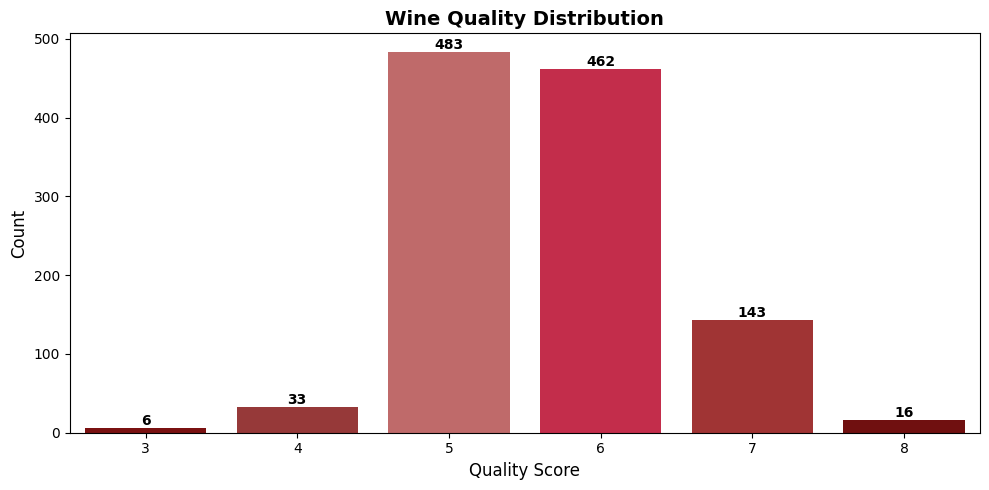

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=quality_counts.index, y=quality_counts.values, palette=gradient, ax=ax)
ax.set_title("Wine Quality Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Quality Score", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
for i, v in enumerate(quality_counts.values):
    ax.text(i, v + 4, f"{v:,}", ha="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()

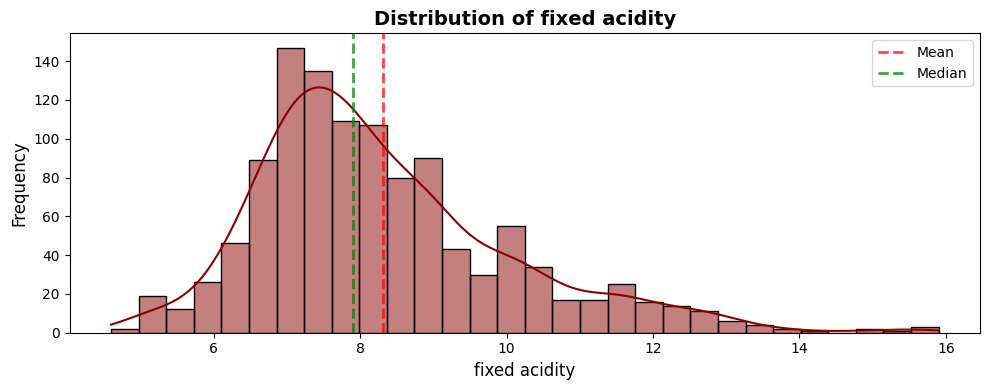

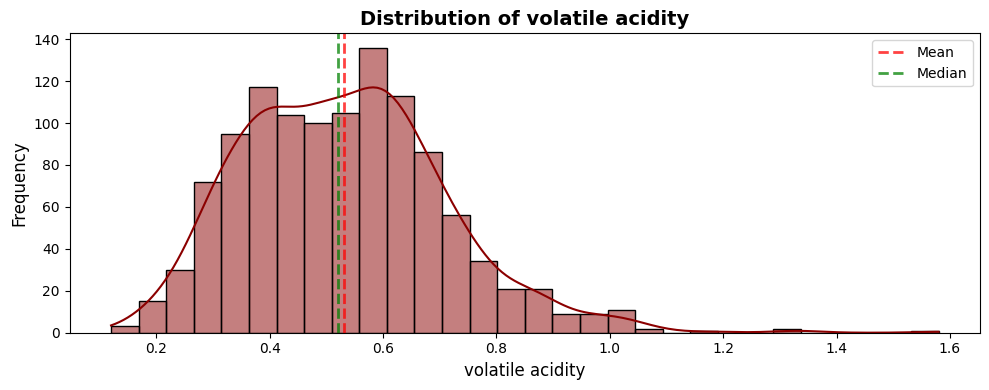

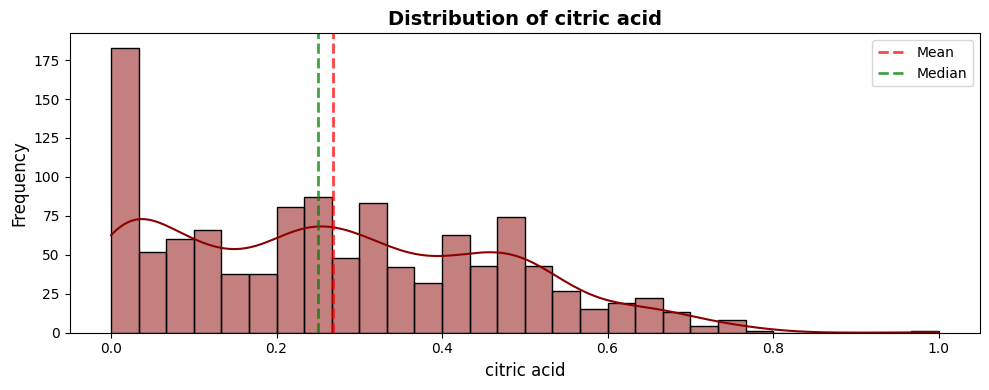

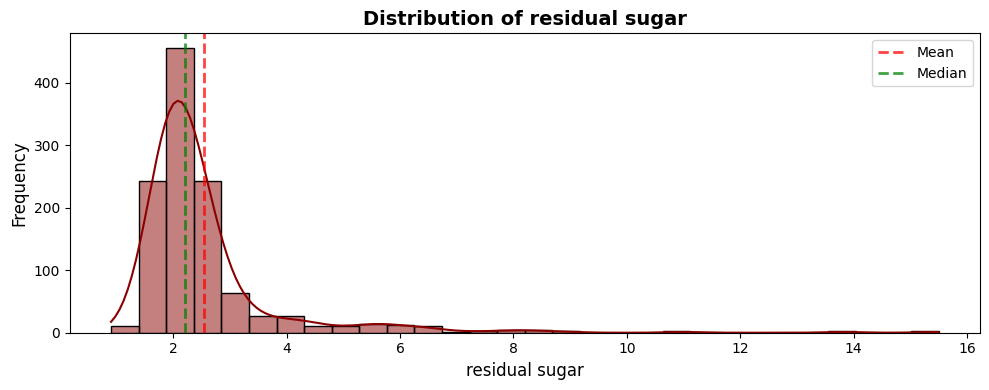

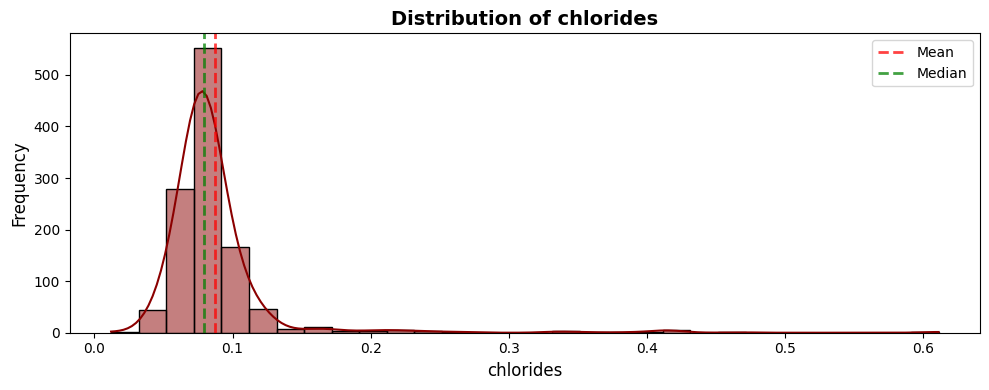

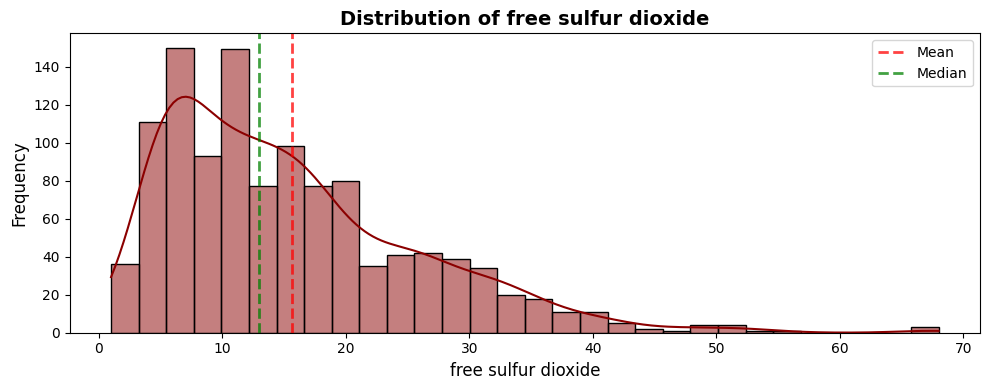

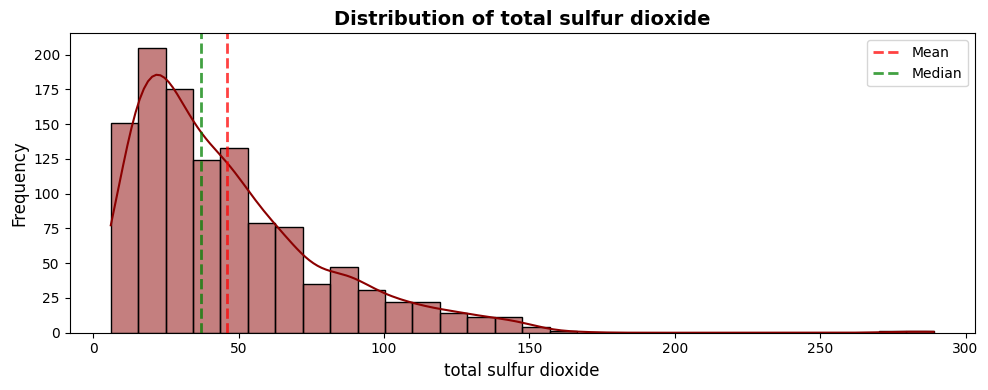

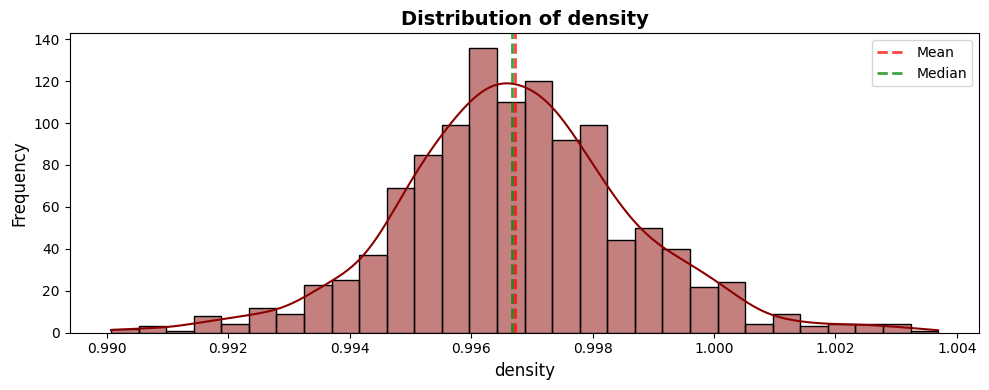

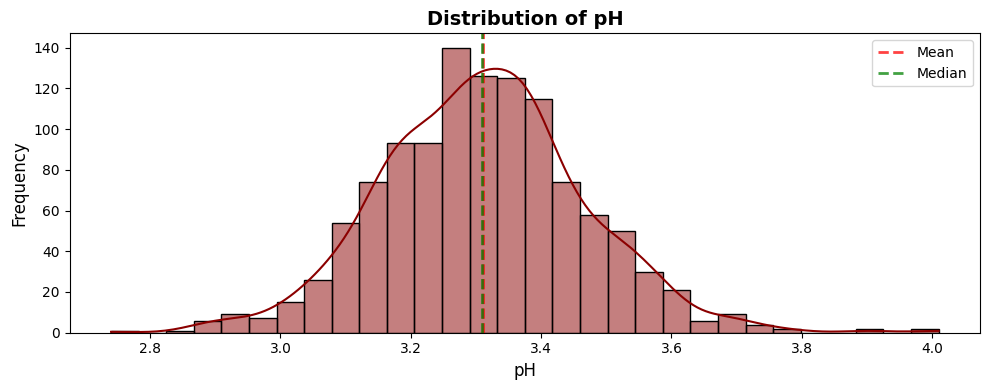

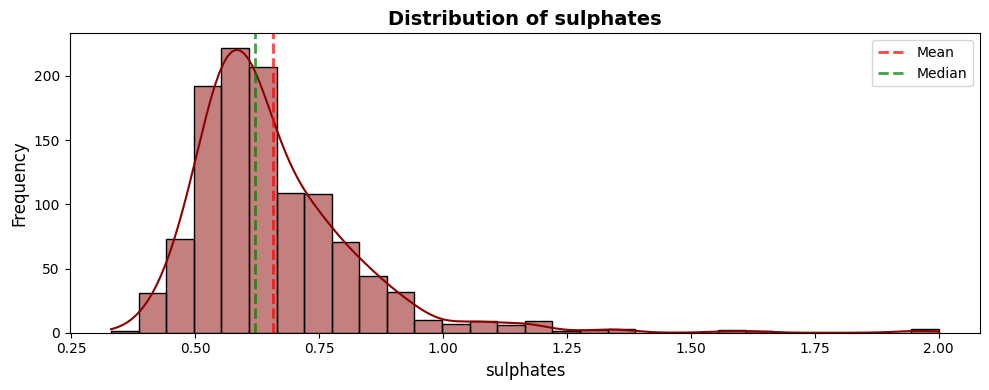

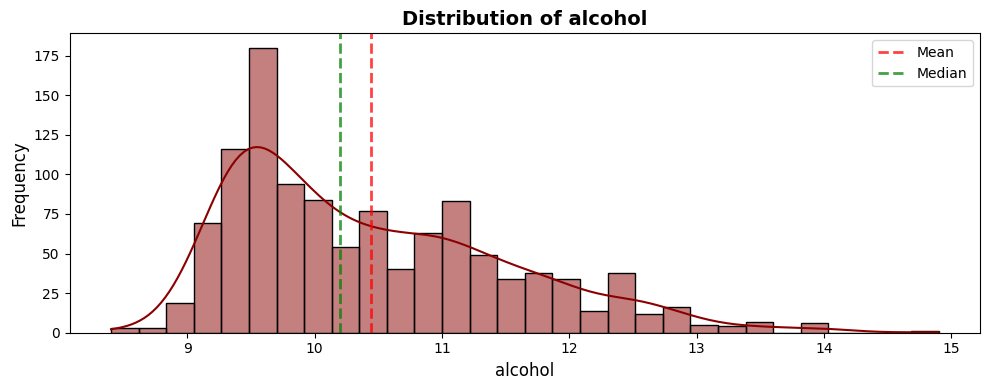

In [32]:
feature_cols = ["fixed acidity", "volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide", "total sulfur dioxide", "density", "pH", "sulphates", "alcohol"]

for col in feature_cols:
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.histplot(df[col], bins=30, kde=True, color=primary, ax=ax)
    ax.set_title(f"Distribution of {col}", fontsize=14, fontweight="bold")
    plt.axvline(df[col].mean(), color="red", linestyle="dashed", linewidth=2, label="Mean", alpha=0.74)
    plt.axvline(df[col].median(), color="green", linestyle="dashed", linewidth=2, label="Median", alpha=0.74)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel("Frequency", fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.show()

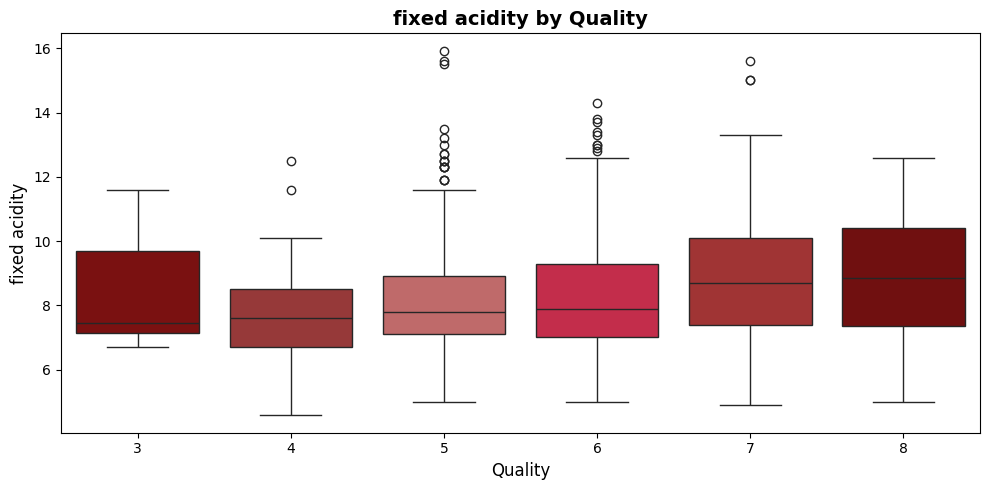

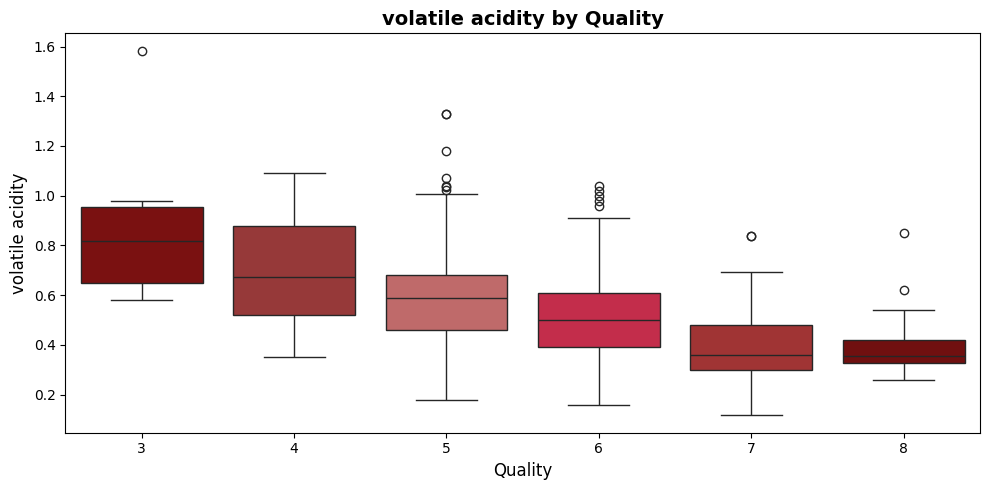

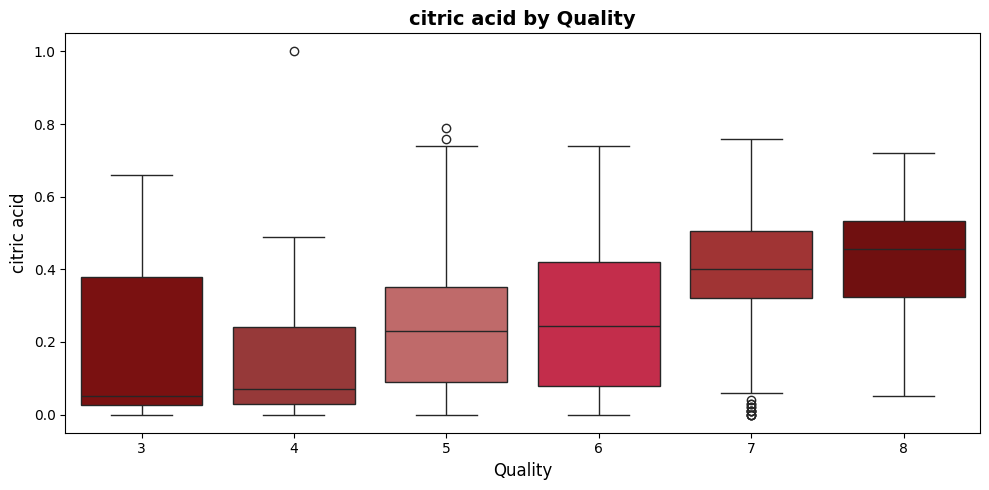

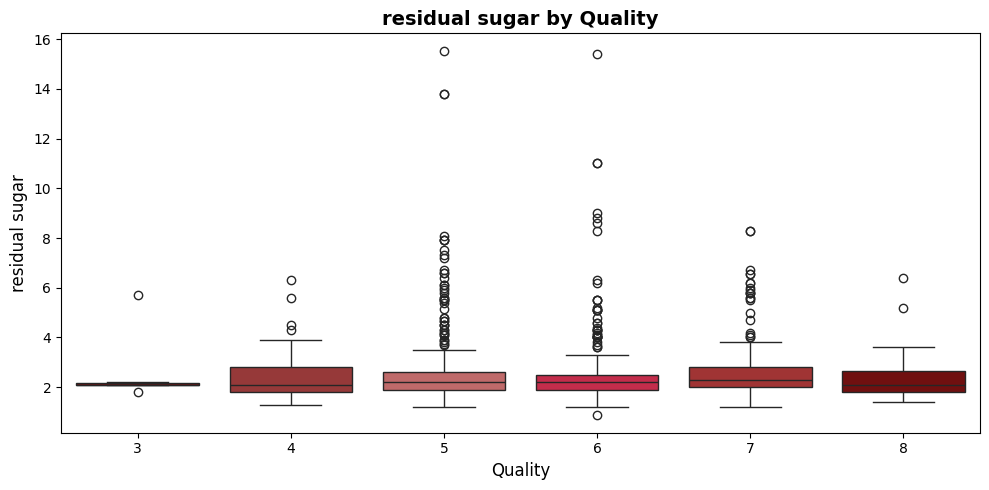

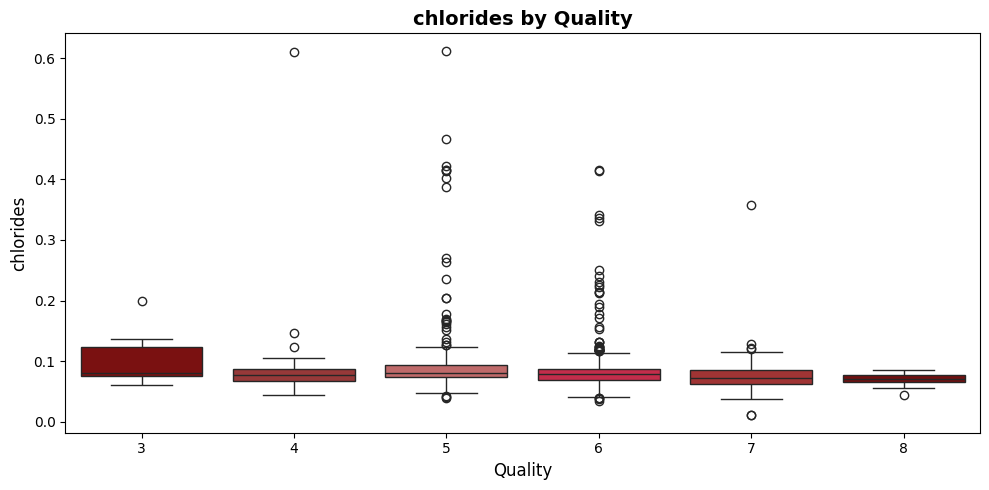

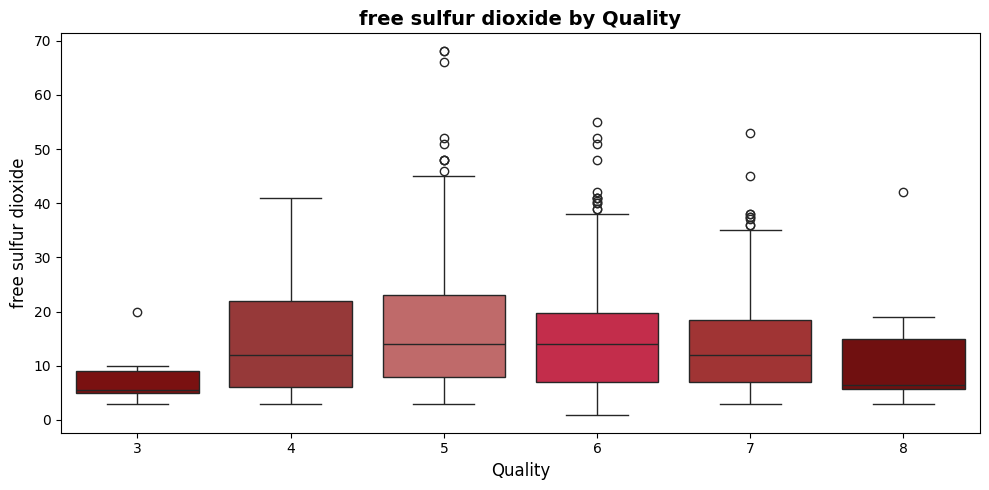

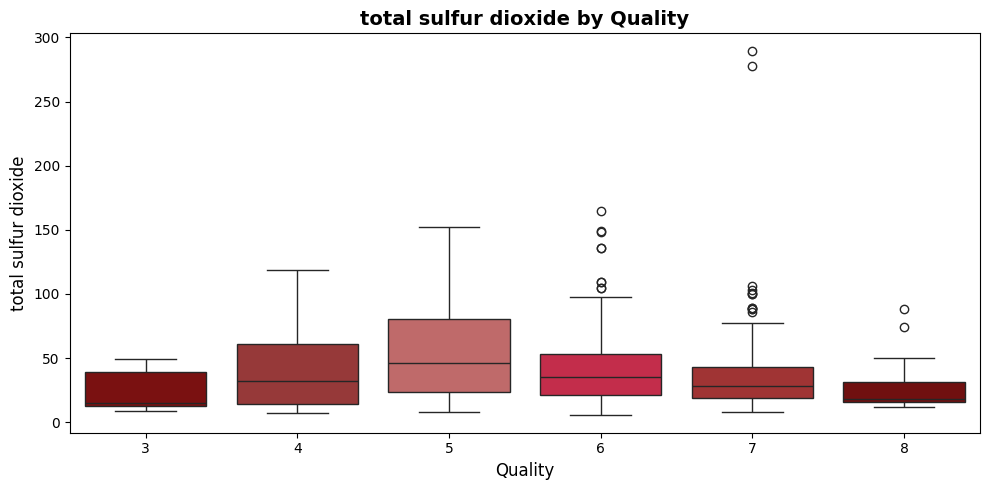

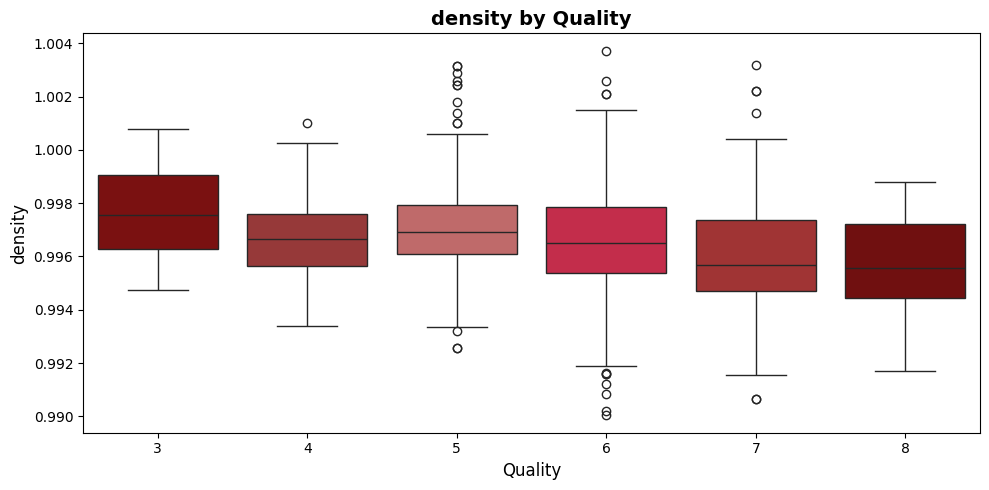

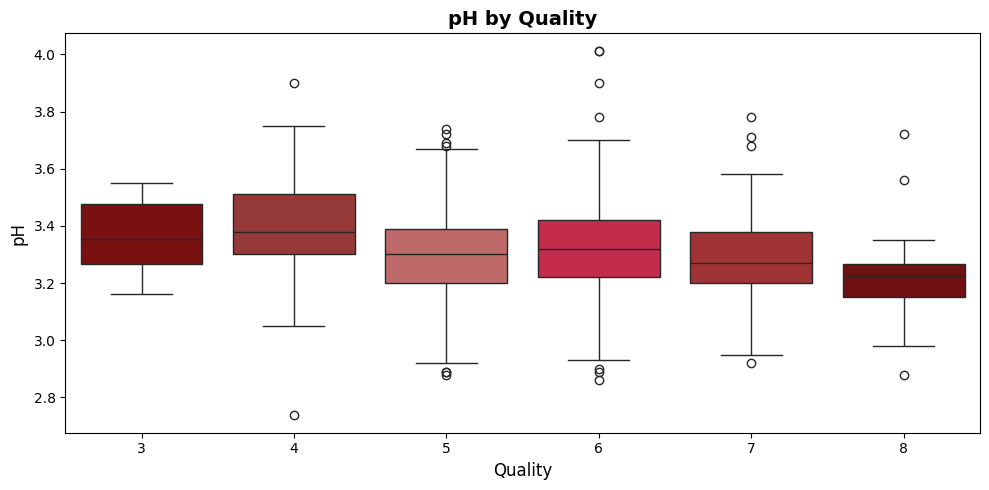

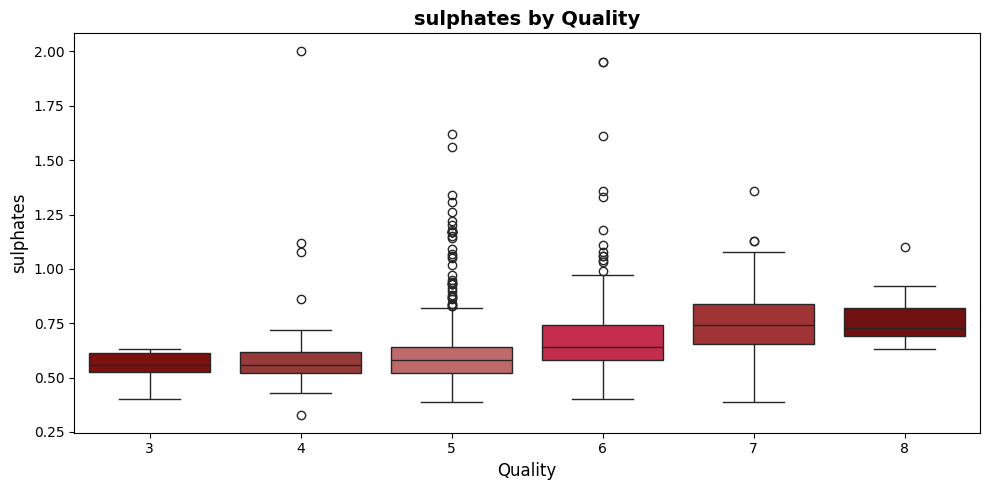

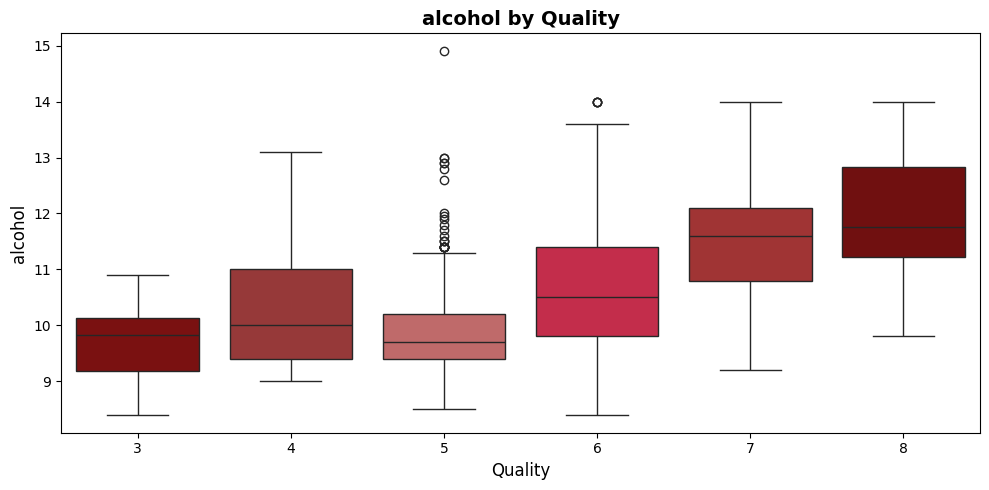

In [11]:
for col in feature_cols:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=df, x="quality", y=col, palette=gradient, ax=ax)
    ax.set_title(f"{col} by Quality", fontsize=14, fontweight="bold")
    ax.set_xlabel("Quality", fontsize=12)
    ax.set_ylabel(col, fontsize=12)
    plt.tight_layout()
    plt.show()

In [12]:
# correlation matrix
corr_matrix = df[feature_cols + ["quality"]].corr()
print("Correlation with quality:")
corr_matrix["quality"].drop("quality").sort_values(ascending=False).round(3)

Correlation with quality:


alcohol                 0.485
sulphates               0.258
citric acid             0.241
fixed acidity           0.122
residual sugar          0.022
pH                     -0.052
free sulfur dioxide    -0.063
chlorides              -0.124
density                -0.175
total sulfur dioxide   -0.183
volatile acidity       -0.407
Name: quality, dtype: float64

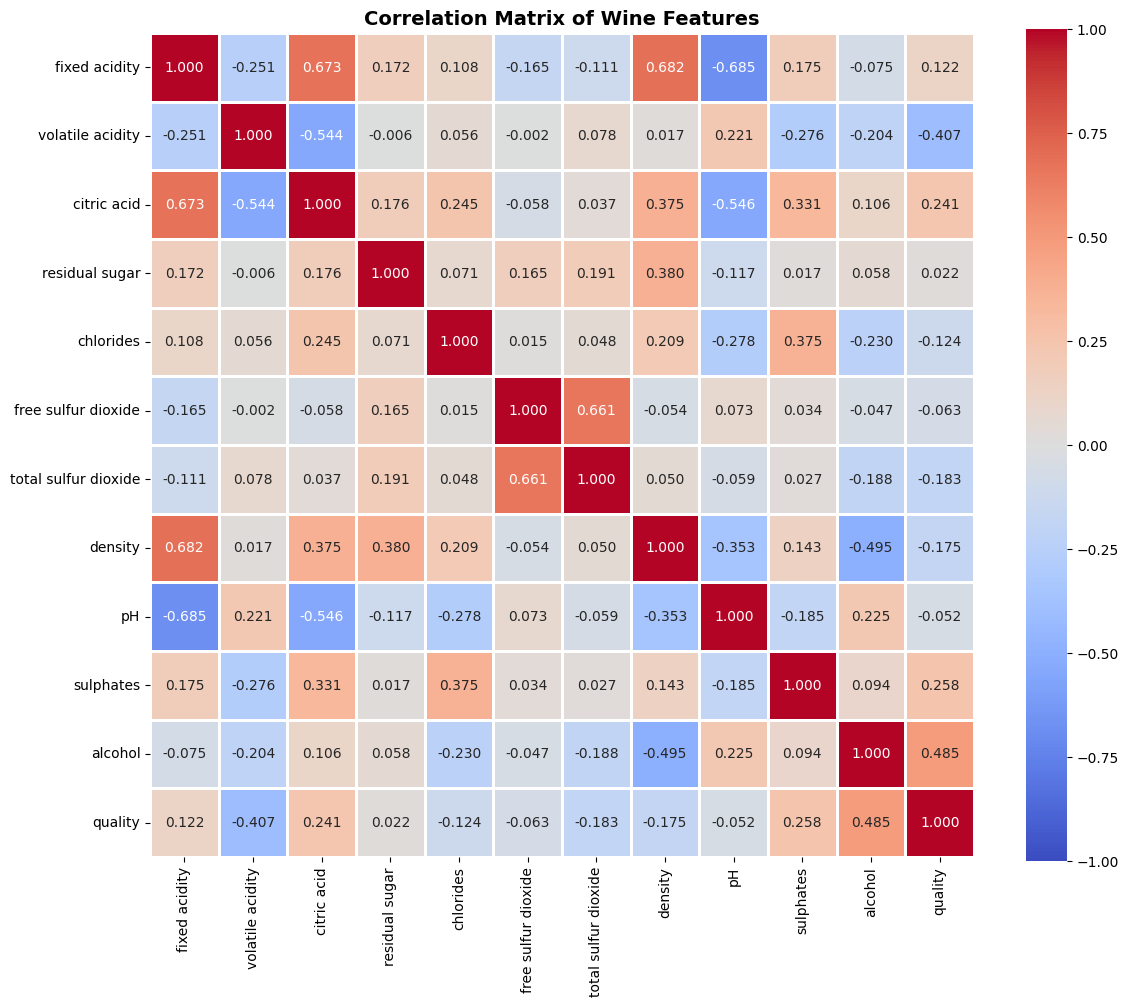

In [13]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".3f", center=0, square=True, linewidths=1, ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation Matrix of Wine Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [14]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("ML libraries imported.")

ML libraries imported.


In [15]:
# prepare features and target
x = df[feature_cols]
y = df["quality"]

# scale features
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# split into train and test
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

print(f"Training set: {len(x_train)} wines")
print(f"Test set: {len(x_test)} wines")

Training set: 914 wines
Test set: 229 wines


In [16]:
# train linear regression model
model = LinearRegression()
model.fit(x_train, y_train)

# predictions
y_pred = model.predict(x_test)

# evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model performance on test set:")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

# cross-validation
cv_scores = cross_val_score(model, x_train, y_train, cv=5, scoring="r2")
print(f"\nCross-validation R² scores: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f}")

Model performance on test set:
MAE: 0.4773
RMSE: 0.6165
R²: 0.3171

Cross-validation R² scores: [0.39107544 0.29391944 0.37925532 0.39730034 0.31120931]
Mean CV R²: 0.3546


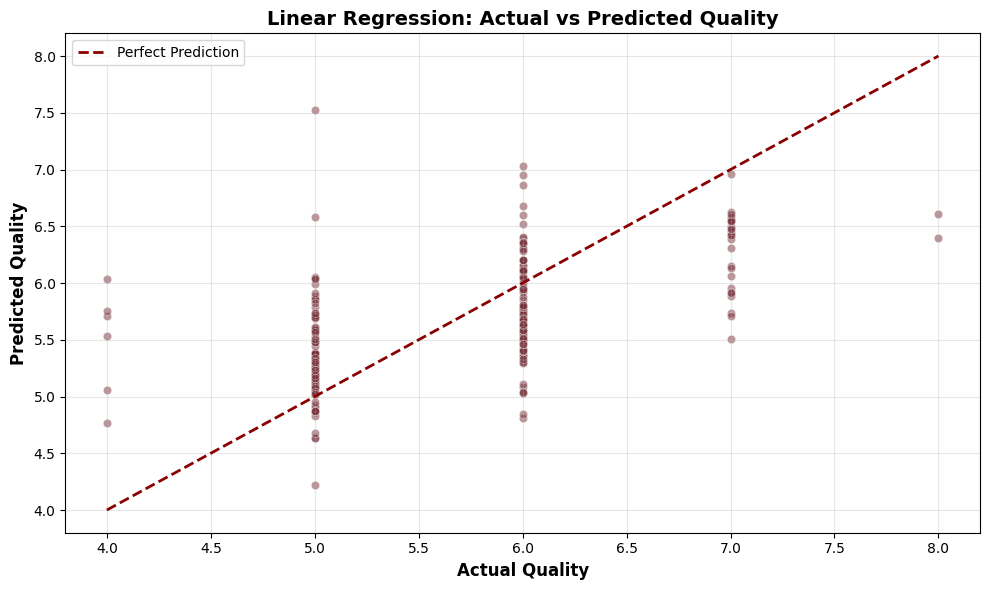

In [17]:
# visualise actual vs predicted
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y_test, y_pred, alpha=0.5, color=secondary, edgecolors='white', linewidth=0.5)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--', color=primary, linewidth=2, label="Perfect Prediction")
ax.set_xlabel("Actual Quality", fontsize=12, fontweight="bold")
ax.set_ylabel("Predicted Quality", fontsize=12, fontweight="bold")
ax.set_title("Linear Regression: Actual vs Predicted Quality", fontsize=14, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

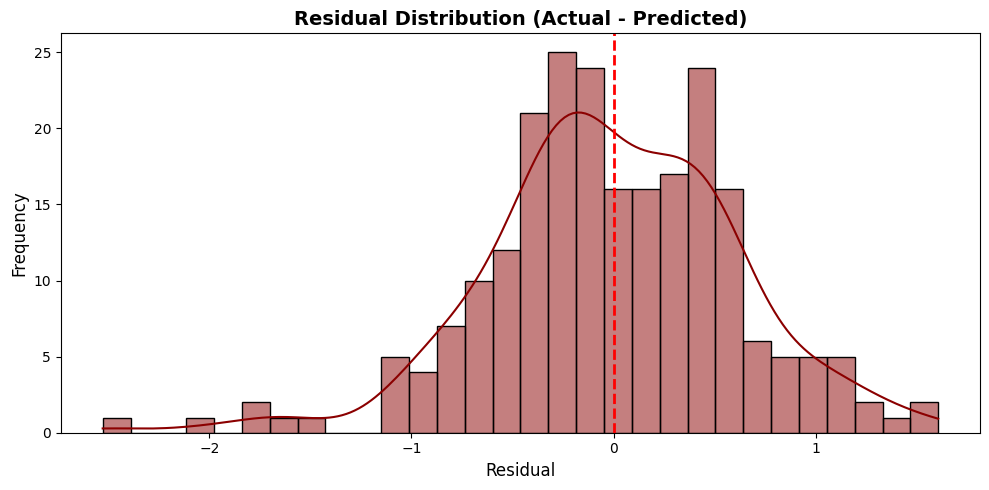

In [18]:
# residual distribution
residuals = y_test - y_pred
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(residuals, bins=30, kde=True, color=primary, ax=ax)
ax.axvline(0, color='red', linestyle='--', linewidth=2)
ax.set_title("Residual Distribution (Actual - Predicted)", fontsize=14, fontweight="bold")
ax.set_xlabel("Residual", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
plt.tight_layout()
plt.show()

In [19]:
# feature coefficients
coefdf = pd.DataFrame({"Feature": feature_cols, "Coefficient": model.coef_}).sort_values("Coefficient", ascending=False)

print("Linear regression coefficients:")
coefdf

Linear regression coefficients:


,Feature,Coefficient
10,alcohol,0.288372
9,sulphates,0.165732
0,fixed acidity,0.089688
5,free sulfur dioxide,0.019270
3,residual sugar,0.005586
8,pH,-0.039029
7,density,-0.058984
2,citric acid,-0.066667
6,total sulfur dioxide,-0.074811
4,chlorides,-0.085353


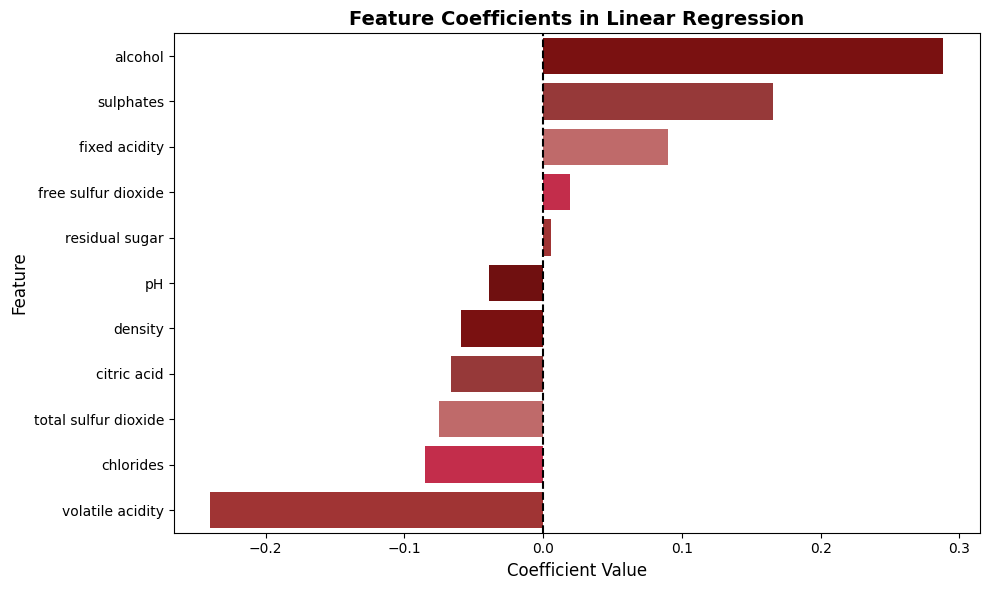

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x="Coefficient", y="Feature", data=coefdf, palette=gradient, ax=ax)
ax.axvline(0, color='black', linestyle='--')
ax.set_title("Feature Coefficients in Linear Regression", fontsize=14, fontweight="bold")
ax.set_xlabel("Coefficient Value", fontsize=12)
ax.set_ylabel("Feature", fontsize=12)
plt.tight_layout()
plt.show()

In [21]:
# saving model
import joblib

joblib.dump(model, "wine_predictor_model.pkl")
print("Model saved as 'wine_predictor_model.pkl'.")

Model saved as 'wine_predictor_model.pkl'.
